In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from tqdm import tqdm
import scipy
from sklearn.metrics import mean_squared_error
sys.path.append('../src')
from data_loader import DataLoader
from configs import SetupEnum, MeasurementDataEnum
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
import scipy.stats as stats
from scipy.stats import multivariate_normal

%matplotlib inline
np.random.seed(777)

In this notebook, Ensemble Kalman filter is introduced to estimate the dynamic system's state espescially Kitti dataset.

- [Ensemble Kalman filter description](#Ensemble-Kalman-filter)
- [Load data](#Load-raw-data-0033)
- [Data visualization](#Display-data-with-noise)
- [Applying Ensemble Kalman filter](#Applying-Ensemble-Kalman-filter)
    - [Setup1](#Setup1-(IMU-input-->-EKF-with-Visual-Odometry-measurement))
        - [Setup1 result](#Setup1-Result)
    - [Setup2](#Setup2-(IMU-input-->-EKF-with-Visual-Odometry-and-GPS-measurement))
        - [Setup2 result](#Setup2-Result)
    - [Setup3](#Setup3-(INS-input-->-EKF-with-Visual-Odometry-and-INS-measurement))
        - [Setup3 result](#Setup3-Result)
- [Result](#Result)

# Ensemble Kalman filter

Ensemble Kalman filter(EnKF), introduced by Evensen in 1994\cite{Evensen1994-za}, is a Monte Carlo approximation of the Kalman filter (KF), in which system's state is represented by samples, a.k.a ensemble member.

In the case of a system that requires a large number of state variables such as numberical weather prediction where the number of variables is $n \approx O(10^{7})$, the classic KF can become expensive to describe the system. The EnKF, on the other hand, estimate the state's uncertainty by the spread in the ensemble at a given time instead of using error covariance matrices \cite{SREnKF}, which reduces computational power required to estimate the system.

The main difference between EnKF and the other sequential Monte Carlo algorithm such as Particle filter is the use of linear updating rule. When new observation is available, each ensemnle member is updated by a linear shift based on the assumption of a linear Gaussian motion model, while the Particle filter uses a resweighting or a resampling approach \cite{Katzfuss2016-xi}, which may experience high-dimensionality problem, called as "curse of dimensionality".

There are many different types of EnKF and they can be classified by two main categories, Stochastic algorithms, such as Perturbed Observation Kalman Filter, and Deterministic algorithms, such as Ensemble Transform Kalman Filter.

Commonly, in the forecast/time update step, forecasted ensemble member is obtained by applying the motion model to each sample and denoted as
\begin{align}
    \tilde{x}^{(i), f}_{k} = M_{k}\hat{x}^{(i), a}_{k} + w^{(i)}_{k}, w^{(i)}_{k} \sim N(0, Q_{k}), i=1,...,N
\end{align}
where the superscript of $\tilde{x}^{(i), f}_{k}$ represents the forecasted ensemble. The $M_{k}$ and $w^{(i)}_{k}$ are motion model of the system and process noise for each ensemble respectively.

In the Perturbed Observation Kalman Filter (POKF), observations are perturbed in order for the variance of the ensemble after the update step to correctly represent the uncertainty in the analysis \cite{EnKF-AFowler}. The update step of the POKF is written as
\begin{align}
    x^{(i), a}_{k} = x^{(i), f}_{k} + K_{k} *(y^{(i)}_{k} - Hx^{(i), f}_{k} )
\end{align}
where $y^{(i)}_{k} = y_{k} + v^{(i)}_{k}$ is a perturbed observations and the measurement noise $v^{(i)}_{k}$ is Gaussian with 0 mean and covariance, $R_{k}$, such that $v^{(i)}_{k} \sim N(0, R_{k})$.

In the Deterministic algorithm, on the other hand, the ensemble member is obtained by deterministically shifting the prior ensemble toward the posterior and scaling the ensemble so that the resulting ensemble has a smaller variance than the prior.


# Load raw data 0033

Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


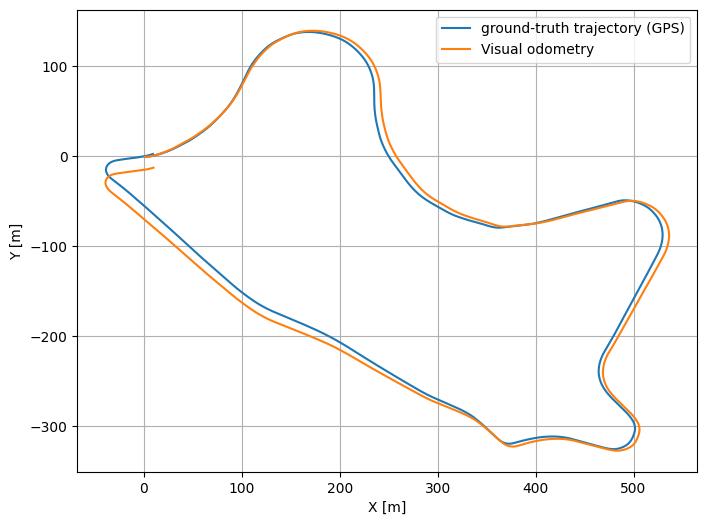

In [2]:
kitti_root_dir = '../data'
kitti_date = '2011_09_30'
kitti_drive = '0033'

data = DataLoader(sequence_nr=kitti_drive, vo_dropout_ratio=0.0, gps_dropout_ratio=0.0)

## Display data with noise

### VO trajectory with noise

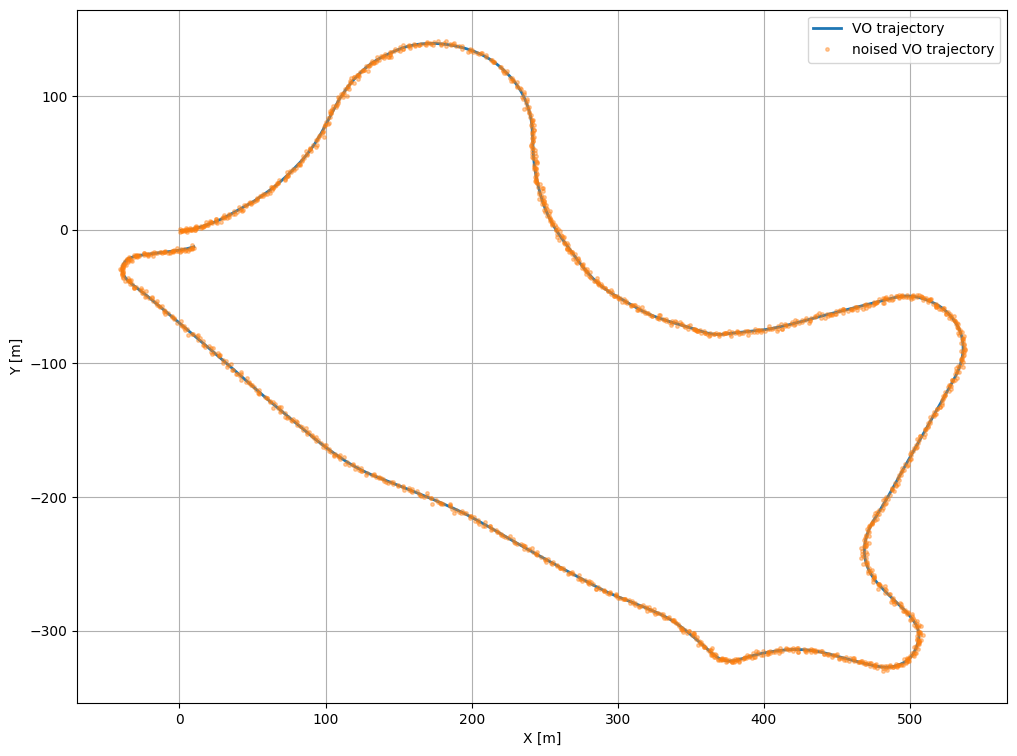

In [3]:
data.show_vo_with_noise()

### Linear acceleration with noise

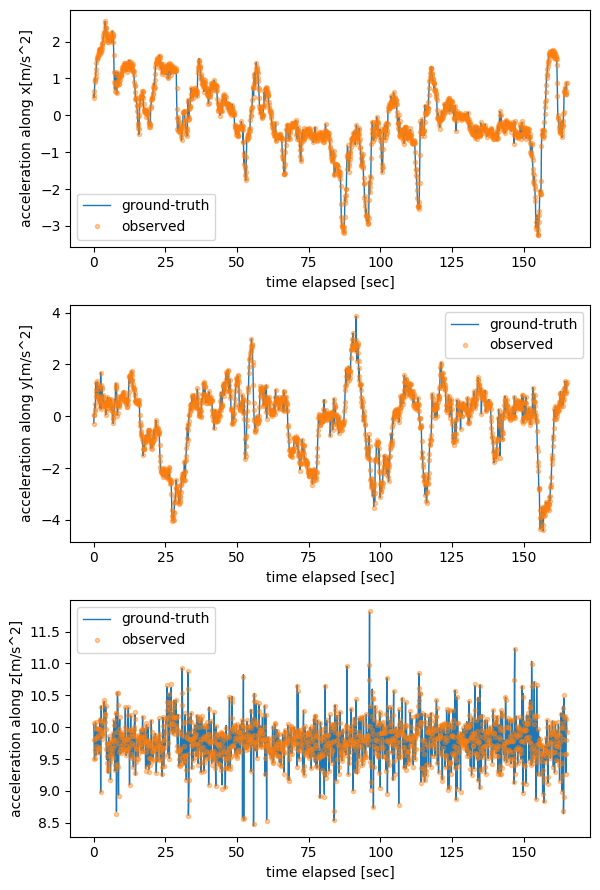

In [4]:
data.show_linear_acceleration_with_noise()

### Angular velocity with noise

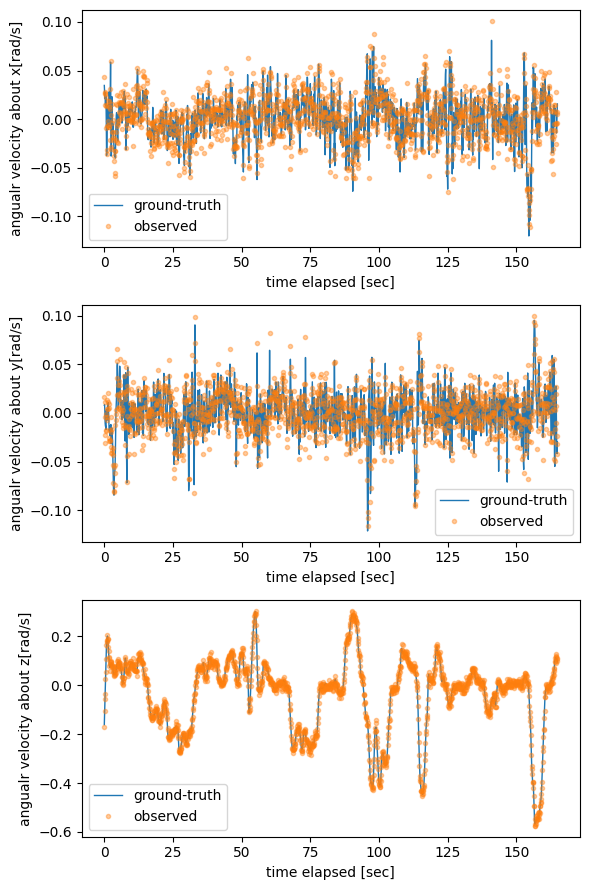

In [5]:
data.show_angular_velocity_with_noise()

### Linear velocity with noise

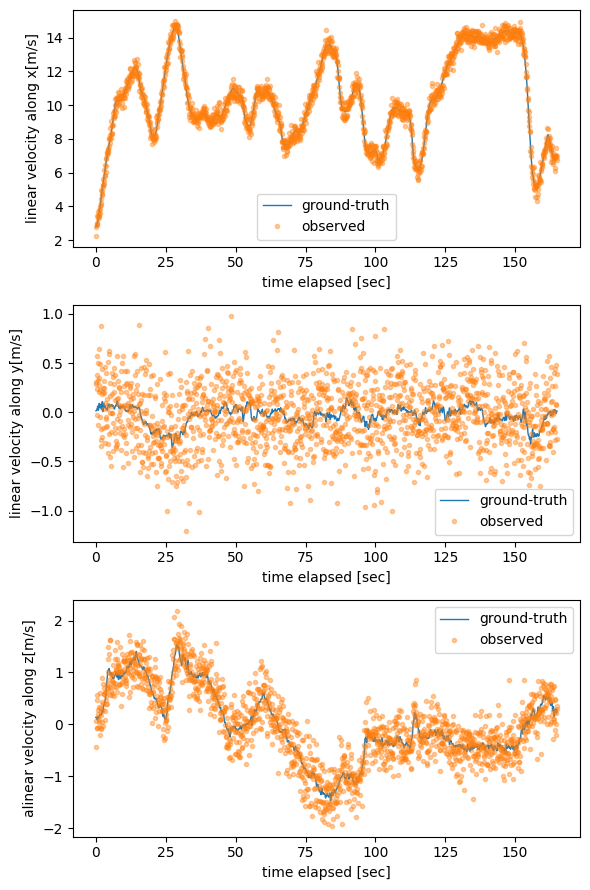

In [6]:
data.show_linear_velocity_with_noise()

# Applying Ensemble Kalman filter

In [3]:
errors = []
error_vo = mean_squared_error(data.GPS_measurements_in_meter.T[:2, :], data.VO_measurements.T[:2, :])
print(f"MSE: {error_vo}")
errors.append(error_vo)

MSE: 29.686680309859263


----

The implementation is based on:
https://filterpy.readthedocs.io/en/latest/_modules/filterpy/kalman/ensemble_kalman_filter.html

In [8]:
class EnsembleKalmanFilter:

    def __init__(self, N, x, P, H):

        self.N = N
        self.x_dim = x.shape[0]
        self.z_dim = H.shape[0]
        self.x = x
        self.H = H
        self.samples = self.generate_ensembles(initial_cov=P)

    def generate_ensembles(self, initial_cov):
        return np.random.multivariate_normal(mean=self.x.reshape(-1), cov=initial_cov, size=self.N)

    def compute_norm_w(self, w):
        return np.sqrt(np.sum(w**2))

    def get_rotation_matrix(self, q):
        q1, q2, q3, q4 = q[:, 0]
        return np.array([
            [q1**2 + q2**2 - q3**2 - q4**2, 2*(q2*q3 - q1*q4), 2*(q1*q3 + q2*q4)],
            [2*(q2*q3 + q1*q4), q1**2 - q2**2 + q3**2 - q4**2, 2*(q3*q4 - q1*q2)],
            [2*(q2*q4 - q1*q3), 2*(q1*q2 + q3*q4), q1**2 - q2**2 - q3**2 + q4**2]
           ])
        
    def get_quaternion_update_matrix(self, w):
        wx, wy, wz = w[:, 0]
        return np.array([
            [0, wz, -wy, wx],
            [-wz, 0, wx, wy],
            [wy, -wx, 0, wz],
            [-wx, -wy, -wz, 0]
        ])
        
    def predict_setup1_2(self, u, dt, Q):
        
        p = self.samples[:, :3]
        v = self.samples[:, 3:6]
        q = self.samples[:, 6:]
        a = u[:3]
        w = u[3:]
        a = a.reshape(-1, 1)
        w = w.reshape(-1, 1)
        g = np.array([[0],[0],[9.81]])
        R = np.array([self.get_rotation_matrix(q_.reshape(-1, 1)) for q_ in q]) #Nx3x3
        omega = self.get_quaternion_update_matrix(w) 
        norm_w = self.compute_norm_w(w)

        A = np.cos(norm_w*dt/2) * np.eye(4)
        B = (1/norm_w)*np.sin(norm_w*dt/2) * omega

        acc_val = (R @ a - g)
        acc_val_reshaped = acc_val.reshape(acc_val.shape[0], acc_val.shape[1])
        p_k = p + v * dt + acc_val_reshaped*dt**2 / 2 # Nx3
        v_k = v + acc_val_reshaped * dt # Nx3
        q_k = q @ np.array(A + B) # Nx4

        process_noise_cov = np.random.multivariate_normal(
                                mean=np.zeros(self.x.shape[0]), 
                                cov=Q, 
                                size=self.N)
        
        self.samples = np.concatenate([
            p_k,
            v_k,
            q_k,
        ], axis=1) + process_noise_cov # Nx10
        
        self.x = np.mean(self.samples, axis=0)
        # P = np.zeros((self.x_dim, self.x_dim))
        # for sample in self.samples:
        #     P += (sample - self.x).reshape(-1, 1) @ (sample - self.x).reshape(-1, 1).T
        # self.P = P / (self.N - 1)
        
    def predict_setup3(self, u, dt, Q):
        v, omega = u
        r = v / omega  # turning radius
        theta = self.samples[:, 2]
        dtheta = omega * dt
        dx = - r * np.sin(theta) + r * np.sin(theta + dtheta)
        dy = + r * np.cos(theta) - r * np.cos(theta + dtheta)
        delta_x = np.concatenate([dx.reshape(-1, 1), 
                                  dy.reshape(-1, 1), 
                                  (np.ones(self.N) * dtheta).reshape(-1, 1)], axis=1)
        process_noise_cov = np.random.multivariate_normal(
                                                mean=np.zeros(self.x.shape[0]), 
                                                cov=Q, 
                                                size=self.N)
        self.samples += delta_x + process_noise_cov
        self.x = np.mean(self.samples, axis=0)
        # P = np.zeros((self.x_dim, self.x_dim))
        # for sample in self.samples:
        #     P += (sample - self.x).reshape(-1, 1) @ (sample - self.x).reshape(-1, 1).T
        # self.P = P / (self.N - 1)
        
    def update(self, z, R):
        samples = self.samples @ self.H.T # Nx2
        y_hat = np.mean(samples, axis=0)
        P_yy = np.zeros((self.z_dim, self.z_dim)) # 2x2
        for sample in samples:
            P_yy += (sample - y_hat).reshape(-1, 1) @ (sample - y_hat).reshape(-1, 1).T
        P_yy /= (self.N-1)
        
        P_xy = np.zeros((self.x_dim, self.z_dim))
        for i, sample in enumerate(self.samples):
            # P_xy += (sample - self.x).reshape(-1, 1) @ (samples[i] - y_hat).reshape(-1, 1).T
            P_xy += np.outer(sample - self.x, samples[i] - y_hat)
        P_xy /= (self.N-1)

        K = P_xy @ np.linalg.inv(P_yy)
        
        measurement_noise = np.random.multivariate_normal(
                                mean=np.zeros(self.z_dim), 
                                cov=R, size=self.N)
        residuals = z - samples + measurement_noise # Nx2
        self.samples = self.samples + residuals @ K.T
        self.x = np.mean(self.samples, axis=0)
        # self.P = self.P - K @ P_yy @ K.T

## Setup1 (IMU input -> EKF with Visual Odometry measurement)

In [4]:
# initial values
px_, py_, pz_ = data.VO_measurements[0, :]
q1_, q2_, q3_, q4_ = data.IMU_quaterion[0]

initial_x_setup1 = np.array([
    [px_], #Px
    [py_], #Py
    [pz_], #Pz
    [0], #Vx
    [0], #Vy
    [0], #Vz
    [q1_], #q1
    [q2_], #q2
    [q3_], #q3
    [q4_]  #q4
])

i = np.eye(initial_x_setup1.shape[0])
# covariance for state vector x
noise = [data.VO_noise_std, 
         data.VO_noise_std, 
         data.VO_noise_std, 
         0.1, 
         0.1, 
         0.1,
         data.IMU_angular_velocity_noise_std, 
         data.IMU_angular_velocity_noise_std, 
         data.IMU_angular_velocity_noise_std, 
         data.IMU_angular_velocity_noise_std]
# initial_P = np.array([[val * num for num in i[ind]] for ind, val in enumerate(noise)]) 
initial_P = np.eye(initial_x_setup1.shape[0]) * 0.1

# transition matrix from predicted state vector to measurement space
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]
])
# process noise
# q_noise = [data.IMU_acc_noise_std, data.IMU_acc_noise_std, data.IMU_acc_noise_std, 
#            data.IMU_angular_velocity_noise_std, data.IMU_angular_velocity_noise_std, data.IMU_angular_velocity_noise_std]
q_noise =  [data.VO_noise_std, 
             data.VO_noise_std, 
             data.VO_noise_std,
             0.1, 
             0.1, 
             0.1,
             data.IMU_angular_velocity_noise_std, 
             data.IMU_angular_velocity_noise_std, 
             data.IMU_angular_velocity_noise_std, 
             data.IMU_angular_velocity_noise_std]
Q = np.array([[val * num for num in i[ind]] for ind, val in enumerate(q_noise)])
# measurement noise
VO_noise_std2 = data.VO_noise_std
R = np.array([
    [VO_noise_std2 ** 2., 0.],
    [0., VO_noise_std2 ** 2.],
])

N_samples = 64

In [10]:
enkf1 = EnsembleKalmanFilter(N=N_samples, 
                               x=initial_x_setup1, 
                               P=initial_P, 
                               H=H)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 826.09it/s]


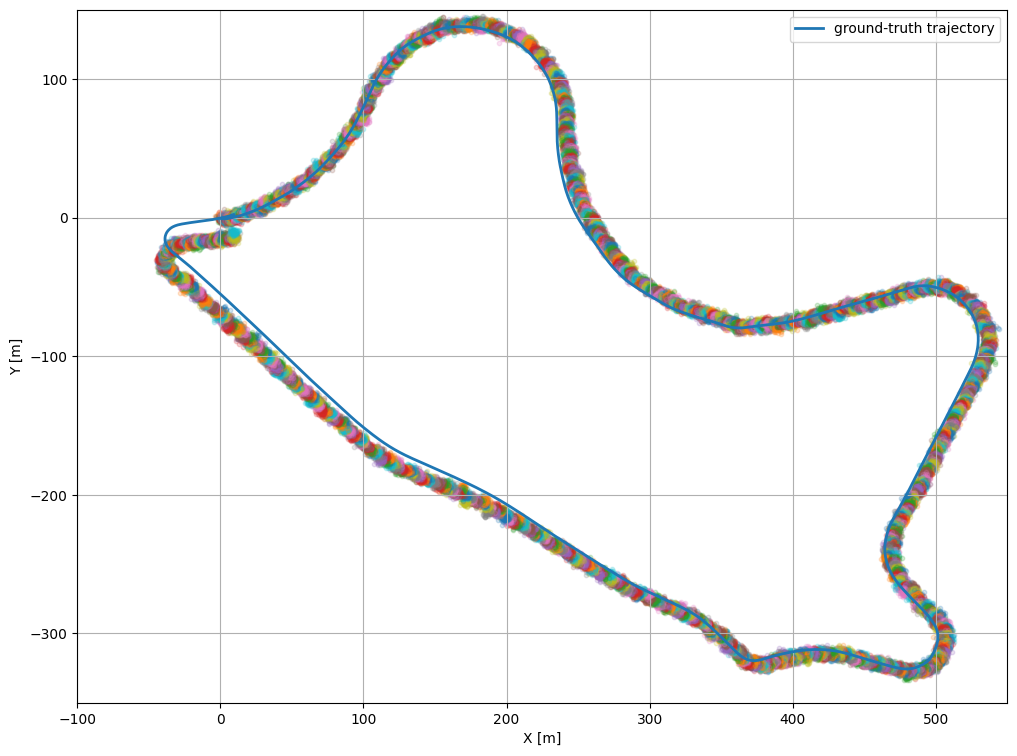

In [11]:

mu_x_enkf1 = [initial_x_setup1[0, 0],]
mu_y_enkf1 = [initial_x_setup1[1, 0],]
t_last = 0.

fig, ax = plt.subplots(1, 1, figsize=(12, 9))
xs, ys, _ = data.GPS_measurements_in_meter.T
ax.plot(xs, ys, lw=2, label='ground-truth trajectory')
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_xlim([-100, 550])
ax.set_ylim([-350, 150])
ax.legend()
ax.grid()

#show only 100 particles in the graph
for t_idx in tqdm(range(1, data.N)):
    t = data.ts[t_idx]
    dt = t - t_last
    ax_, ay_, az_ = data.IMU_acc_with_noise[t_idx]
    wx_, wy_, wz_ = data.IMU_angular_velocity_with_noise[t_idx]
    u_ = np.array([
        ax_,
        ay_,
        az_,
        wx_,
        wy_,
        wz_
    ])
    enkf1.predict_setup1_2(u=u_, dt=dt, Q=Q)
    
    x_hat = enkf1.x.copy()
    mu_x_enkf1.append(x_hat[0])
    mu_y_enkf1.append(x_hat[1])

    if enkf1.N > 100:
        samples_indices = np.linspace(0, enkf1.N-1, 100, dtype=int).tolist()
        ax.scatter(enkf1.samples[samples_indices, 0], enkf1.samples[samples_indices, 1], alpha=.2, s=[10])
    else:
        ax.scatter(enkf1.samples[:, 0], enkf1.samples[:, 1], alpha=.2, s=[10])
       
    # z_ = data.VO_measurements_with_noise[t_idx, :2]
    # enkf1.update(z=z_, R=R_)
    
    z_ = data.get_vo_measurement(t_idx)
    if z_ is not None:
        enkf1.update(z=z_.reshape(-1), R=R)

    # z_, vo_noise_ = data.get_vo_measurement_with_noise_cov(t_idx)
    # R_ = np.array([
    #         [vo_noise_ ** 2., 0.],
    #         [0., vo_noise_ ** 2.],
    #     ])
    # enkf1.update(z=z_, R=R_)

    t_last = t


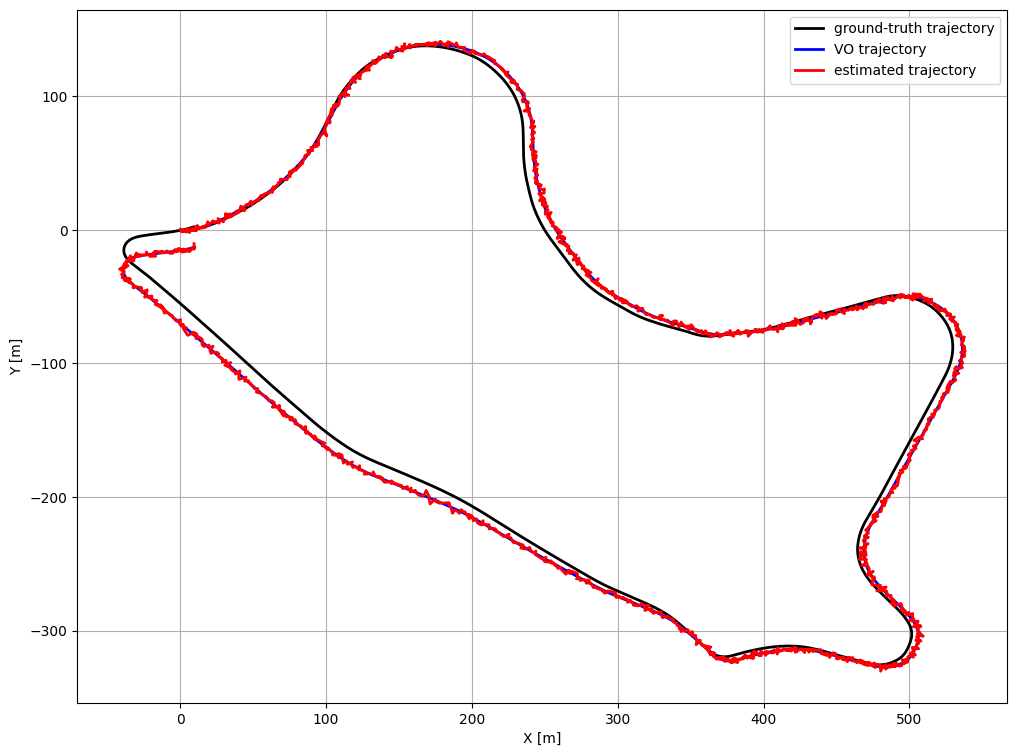

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(12, 9))

xs, ys, _ = data.GPS_measurements_in_meter.T
ax.plot(xs, ys, lw=2, label='ground-truth trajectory', color='black')

xs, ys, _ = data.VO_measurements.T
ax.plot(xs, ys, lw=2, markersize=4, alpha=1., label='VO trajectory', color='b')

ax.plot(mu_x_enkf1, mu_y_enkf1, lw=2, label='estimated trajectory', color='r')

ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.legend()
ax.grid()

### Setup1 Result

In [13]:
error_enkf1 = mean_squared_error(data.GPS_measurements_in_meter.T[:2, :len(mu_x_enkf1)], np.array([mu_x_enkf1, mu_y_enkf1]))
print(f"MSE: {error_enkf1}")
errors.append(error_enkf1)

MSE: 30.99826835268503


## Setup2 (IMU input -> EKF with Visual Odometry and GPS measurement)

In [14]:
# initial values
px_, py_, pz_ = data.VO_measurements[0, :]
q1_, q2_, q3_, q4_ = data.IMU_quaterion[0]

initial_x_setup2 = np.array([
    [px_], #Px
    [py_], #Py
    [pz_], #Pz
    [0], #Vx
    [0], #Vy
    [0], #Vz
    [q1_], #q1
    [q2_], #q2
    [q3_], #q3
    [q4_]  #q4
])

i = np.eye(initial_x_setup2.shape[0])
# covariance for state vector x
noise = [data.VO_noise_std, 
         data.VO_noise_std, 
         data.VO_noise_std, 
         0.1, 
         0.1, 
         0.1,
         data.IMU_angular_velocity_noise_std, 
         data.IMU_angular_velocity_noise_std, 
         data.IMU_angular_velocity_noise_std, 
         data.IMU_angular_velocity_noise_std]
# initial_P = np.array([[val * num for num in i[ind]] for ind, val in enumerate(noise)]) 
initial_P = np.eye(initial_x_setup2.shape[0]) * 0.1

# transition matrix from predicted state vector to measurement space
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]
])
# process noise
# q_noise = [data.IMU_acc_noise_std, data.IMU_acc_noise_std, data.IMU_acc_noise_std, 
#            data.IMU_angular_velocity_noise_std, data.IMU_angular_velocity_noise_std, data.IMU_angular_velocity_noise_std]
q_noise =  [data.VO_noise_std, 
             data.VO_noise_std, 
             data.VO_noise_std,
             0.1, 
             0.1, 
             0.1,
             data.IMU_angular_velocity_noise_std, 
             data.IMU_angular_velocity_noise_std, 
             data.IMU_angular_velocity_noise_std, 
             data.IMU_angular_velocity_noise_std]
Q = np.array([[val * num for num in i[ind]] for ind, val in enumerate(q_noise)])
# measurement noise
VO_noise_std_2 = data.VO_noise_std
GPS_measurement_noise_std_2 = data.GPS_measurement_noise_std
R_vo = np.array([
    [VO_noise_std_2 ** 2., 0.],
    [0., VO_noise_std_2 ** 2.]
])
R_gps = np.array([
    [GPS_measurement_noise_std_2 ** 2., 0.],
    [0., GPS_measurement_noise_std_2 ** 2.]
])

N_samples = 256

In [15]:
enkf2 = EnsembleKalmanFilter(N=N_samples, 
                           x=initial_x_setup2, 
                           P=initial_P, 
                           H=H)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:06<00:00, 259.28it/s]


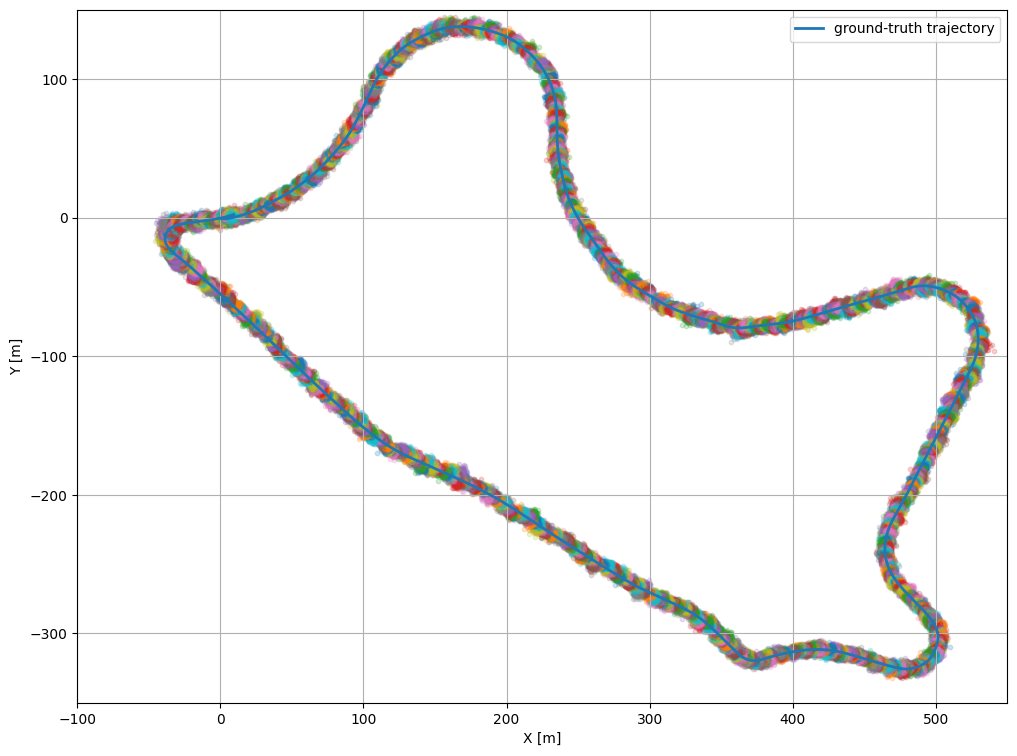

In [16]:

mu_x_enkf2 = [initial_x_setup1[0, 0],]
mu_y_enkf2 = [initial_x_setup1[1, 0],]
t_last = 0.

fig, ax = plt.subplots(1, 1, figsize=(12, 9))
xs, ys, _ = data.GPS_measurements_in_meter.T
ax.plot(xs, ys, lw=2, label='ground-truth trajectory')
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_xlim([-100, 550])
ax.set_ylim([-350, 150])
ax.legend()
ax.grid()

#show only 100 particles in the graph
for t_idx in tqdm(range(1, data.N)):
    t = data.ts[t_idx]
    dt = t - t_last
    ax_, ay_, az_ = data.IMU_acc_with_noise[t_idx]
    wx_, wy_, wz_ = data.IMU_angular_velocity_with_noise[t_idx]
    u_ = np.array([
        ax_,
        ay_,
        az_,
        wx_,
        wy_,
        wz_
    ])
    enkf2.predict_setup1_2(u=u_, dt=dt, Q=Q)
    
    x_hat = enkf2.x.copy()
    mu_x_enkf2.append(x_hat[0])
    mu_y_enkf2.append(x_hat[1])

    if enkf2.N > 100:
        samples_indices = np.linspace(0, enkf2.N-1, 100, dtype=int).tolist()
        ax.scatter(enkf2.samples[samples_indices, 0], enkf2.samples[samples_indices, 1], alpha=.2, s=[10])
    else:
        ax.scatter(enkf2.samples[:, 0], enkf2.samples[:, 1], alpha=.2, s=[10])
       
    # vo_z_ = data.VO_measurements_with_noise[t_idx, :2]
    # enkf2.update(z=vo_z_, R=R_vo)
    # gps_z_ = data.VO_measurements_with_noise[t_idx, :2]
    # enkf2.update(z=gps_z_, R=R_gps)
    
    vo_z_ = data.get_vo_measurement(t_idx)
    gps_z_ = data.get_gps_measurement(t_idx)
    if vo_z_ is not None:
        enkf2.update(z=vo_z_.reshape(-1), R=R_vo)
    if gps_z_ is not None:
        enkf2.update(z=gps_z_.reshape(-1), R=R_gps)

    # vo_z_, vo_noise_ = data.get_vo_measurement_with_noise_cov(t_idx)
    # gps_z_, gps_noise_ = data.get_gps_measurement_with_noise_cov(t_idx)
    # R_vo = np.array([
    #         [vo_noise_ ** 2., 0.],
    #         [0., vo_noise_ ** 2.],
    #     ])
    # R_gps = np.array([
    #     [gps_noise_ ** 2., 0.],
    #     [0., gps_noise_ ** 2.]
    # ])
    # ukf2.update(z=vo_z_, R=R_vo)
    # ukf2.update(z=gps_z_, R=R_gps)

    t_last = t


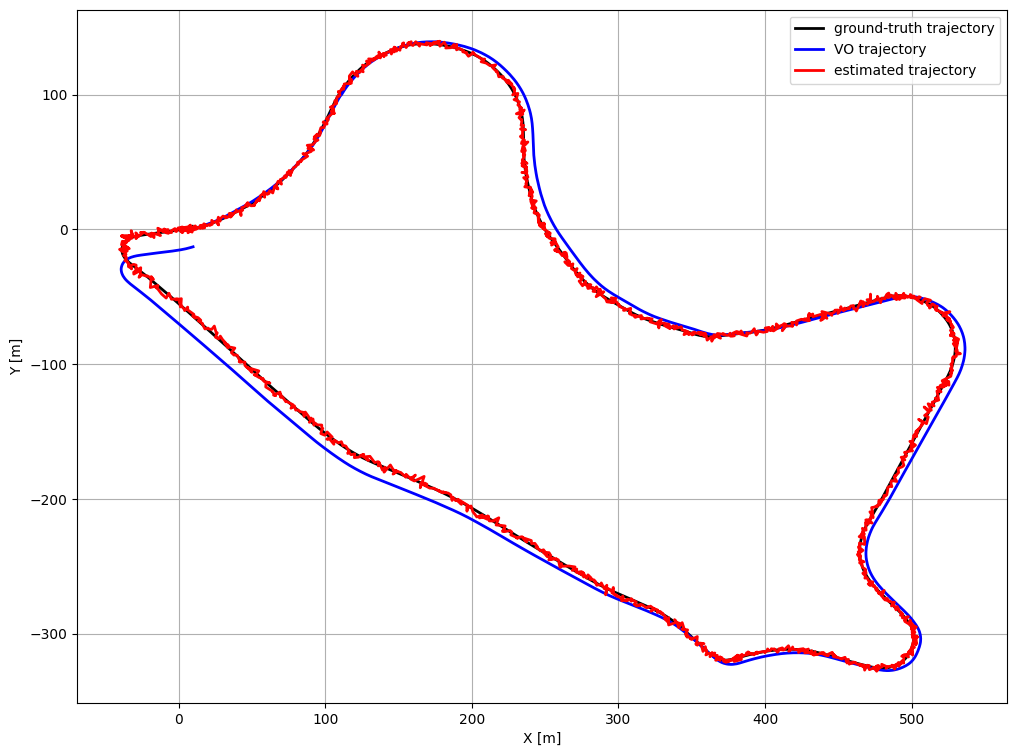

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(12, 9))

xs, ys, _ = data.GPS_measurements_in_meter.T
ax.plot(xs, ys, lw=2, label='ground-truth trajectory', color='black')

xs, ys, _ = data.VO_measurements.T
ax.plot(xs, ys, lw=2, label='VO trajectory', color='b')

ax.plot(mu_x_enkf2, mu_y_enkf2, lw=2, label='estimated trajectory', color='r')

ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.legend()
ax.grid()

### Setup2 Result

In [18]:
error_enkf2 = mean_squared_error(data.GPS_measurements_in_meter.T[:2, :len(mu_x_enkf2)], np.array([mu_x_enkf2, mu_y_enkf2]))
print(f"MSE: {error_enkf2}")
errors.append(error_enkf2)

MSE: 2.201140930120679


## Setup3 (INS input -> EKF with Visual Odometry and INS measurement)

In [19]:
# state vector x
initial_x_setup3 = np.array([
    data.VO_measurements[0, 0], #Px
    data.VO_measurements[0, 1], #Py
    data.IMU_outputs[0, 5]
])
initial_x_setup3 = initial_x_setup3.reshape(-1, 1)

# covariance for state vector x
initial_P = np.eye(initial_x_setup3.shape[0]) * 0.1

# process noise
# q_noise3 = [data.velocity_noise_std, data.IMU_angular_velocity_noise_std]
# i = np.eye(2)
# Q_ = np.array([[val * num for num in i[ind]] for ind, val in enumerate(q_noise3)])
velocity_noise_std2 = data.velocity_noise_std
IMU_angular_velocity_noise_std2 = data.IMU_angular_velocity_noise_std
Q = np.array([
    [velocity_noise_std2 ** 2., 0., 0.],
    [0., velocity_noise_std2 ** 2., 0.],
    [0., 0., IMU_angular_velocity_noise_std2 ** 2.],
])

# measurement noise
VO_noise_std2 = data.VO_noise_std
GPS_measurement_noise_std2 = data.GPS_measurement_noise_std
R_vo = np.array([
    [VO_noise_std2 ** 2., 0.],
    [0., VO_noise_std2 ** 2.]
])
R_gps = np.array([
    [GPS_measurement_noise_std2 ** 2., 0.],
    [0., GPS_measurement_noise_std2 ** 2.]
])


# transition matrix H
H = np.array([
    [1., 0., 0.],
    [0., 1., 0.]
])

N_samples = 64

In [20]:
enkf3 = EnsembleKalmanFilter(N=N_samples, 
                           x=initial_x_setup3, 
                           P=initial_P, 
                           H=H)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 787.22it/s]


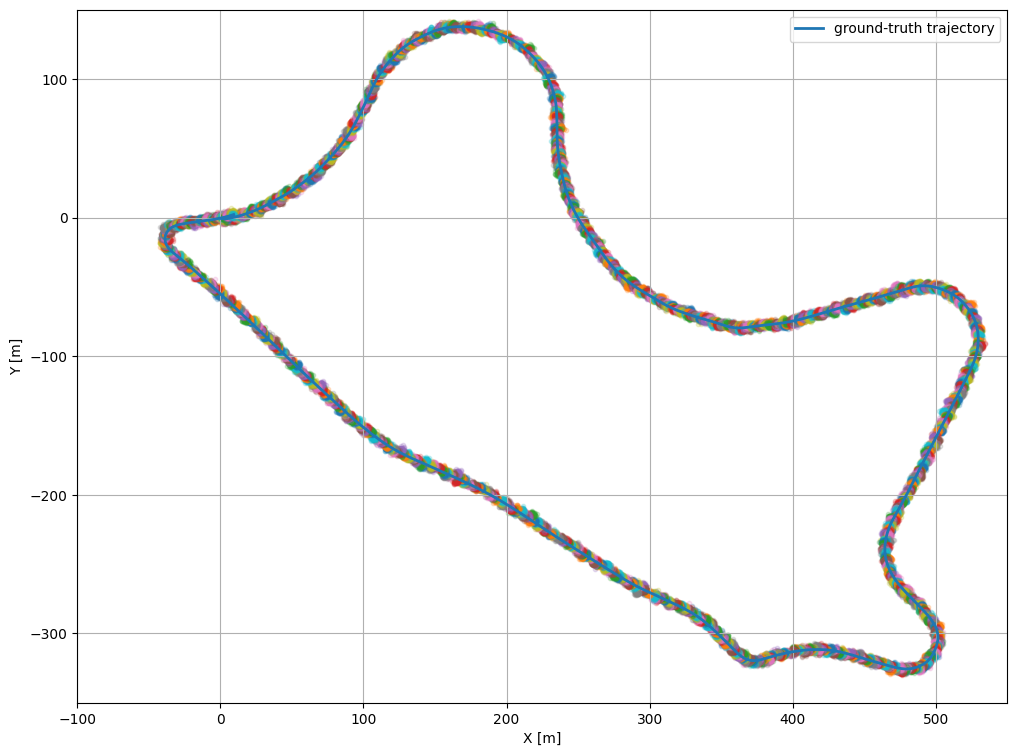

In [21]:

mu_x_enkf3 = [initial_x_setup3[0, 0],]
mu_y_enkf3 = [initial_x_setup3[1, 0],]
t_last = 0.

fig, ax = plt.subplots(1, 1, figsize=(12, 9))
xs, ys, _ = data.GPS_measurements_in_meter.T
ax.plot(xs, ys, lw=2, label='ground-truth trajectory')
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_xlim([-100, 550])
ax.set_ylim([-350, 150])
ax.legend()
ax.grid()

#show only 100 particles in the graph
for t_idx in tqdm(range(1, data.N)):
    t = data.ts[t_idx]
    dt = t - t_last
    vf_ = data.INS_velocities_with_noise[t_idx, 0] # forward velocity
    wz_ = data.IMU_angular_velocity_with_noise[t_idx, 2]
    u_ = np.array([
        vf_,
        wz_,
    ])
    enkf3.predict_setup3(u=u_, dt=dt, Q=Q)
    
    x_hat = enkf3.x.copy()
    mu_x_enkf3.append(x_hat[0])
    mu_y_enkf3.append(x_hat[1])

    if enkf3.N > 100:
        samples_indices = np.linspace(0, enkf3.N-1, 100, dtype=int).tolist()
        ax.scatter(enkf3.samples[samples_indices, 0], enkf3.samples[samples_indices, 1], alpha=.2, s=[10])
    else:
        ax.scatter(enkf3.samples[:, 0], enkf3.samples[:, 1], alpha=.2, s=[10])
       
    # vo_z_ = data.VO_measurements_with_noise[t_idx, :2]
    # enkf3.update(z=vo_z_, R=R_vo)
    # gps_z_ = data.VO_measurements_with_noise[t_idx, :2]
    # enkf3.update(z=gps_z_, R=R_gps)
    
    vo_z_ = data.get_vo_measurement(t_idx)
    gps_z_ = data.get_gps_measurement(t_idx)
    if vo_z_ is not None:
        enkf3.update(z=vo_z_.reshape(-1), R=R_vo)
    if gps_z_ is not None:
        enkf3.update(z=gps_z_.reshape(-1), R=R_gps)

    # vo_z_, vo_noise_ = data.get_vo_measurement_with_noise_cov(t_idx)
    # gps_z_, gps_noise_ = data.get_gps_measurement_with_noise_cov(t_idx)
    # R_vo = np.array([
    #         [vo_noise_ ** 2., 0.],
    #         [0., vo_noise_ ** 2.],
    #     ])
    # R_gps = np.array([
    #     [gps_noise_ ** 2., 0.],
    #     [0., gps_noise_ ** 2.]
    # ])
    # ukf2.update(z=vo_z_, R=R_vo)
    # ukf2.update(z=gps_z_, R=R_gps)

    t_last = t


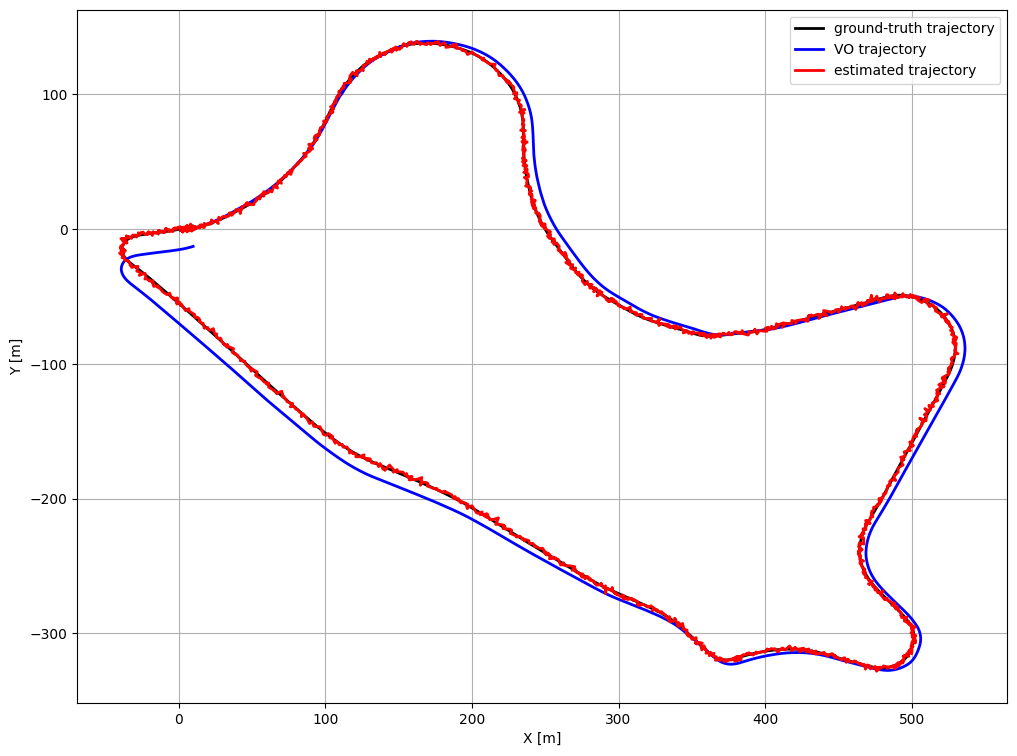

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(12, 9))

xs, ys, _ = data.GPS_measurements_in_meter.T
ax.plot(xs, ys, lw=2, label='ground-truth trajectory', color='black')

xs, ys, _ = data.VO_measurements.T
ax.plot(xs, ys, lw=2, label='VO trajectory', color='b')

ax.plot(mu_x_enkf3, mu_y_enkf3, lw=2, label='estimated trajectory', color='r')

ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.legend()
ax.grid()

### Setup3 Result

In [23]:
error_enkf3 = mean_squared_error(data.GPS_measurements_in_meter.T[:2, :], np.array([mu_x_enkf3, mu_y_enkf3]))
print(f"MSE: {error_enkf3}")
errors.append(error_enkf3)

MSE: 1.1020149748549066


# Result

In [24]:
error_labels = ["VO MSE error", "EnKF (input:IMU, mesurement:VO)", 
                "EnKF (input:IMU, measurements:VO, GPS)", "EnKF (input:INS, measurements:VO, INS)"]
error_pd = pd.DataFrame(np.array(errors).reshape(1, -1), columns=error_labels)
error_pd

,VO MSE error,"EnKF (input:IMU, mesurement:VO)","EnKF (input:IMU, measurements:VO, GPS)","EnKF (input:INS, measurements:VO, INS)"
0,29.68668,30.998268,2.201141,1.102015
